In [104]:
rec = sess.recordings["recording_0"]

In [105]:
print(rec.signals.keys())

dict_keys(['present', 'ear_l', 'ear_r', 'mar', 'kss_pre', 'kss_post', 'resp_sensor', 'oxi_sensor', 'eda_sensor'])


In [106]:
for name in rec.signals.keys():
    sig = rec.signals[name]

    try:
        print(
            name,
            "samples =", sig.get_num_samples(),
            "fs =", sig.avg_fs()
        )
    except:
        print(name)

present samples = 1719 fs = 9.671580331225146e-07
ear_l samples = 1719 fs = 9.671580331225146e-07
ear_r samples = 1719 fs = 9.671580331225146e-07
mar samples = 1719 fs = 9.671580331225146e-07
kss_pre
kss_post
resp_sensor samples = 60000 fs = 1000.0
oxi_sensor samples = 60000 fs = 1000.0
eda_sensor samples = 60000 fs = 1000.0


In [107]:
 import matplotlib.pyplot as plt

In [108]:
for signal_name in ["oxi_sensor", "resp_sensor", "eda_sensor", "ecg_sensor"]:

    signal = rec.signals[signal_name]
    data = signal.data_np()

    print("\n", signal_name)
    print("Shape:", data.shape)
    print("Min:", data.min())
    print("Max:", data.max())
    print("First 20 values:")
    print(data[:20])


 oxi_sensor
Shape: (60000,)
Min: 395.0
Max: 644.0
First 20 values:
[519. 519. 519. 519. 520. 520. 520. 521. 521. 521. 521. 521. 523. 522.
 522. 523. 522. 522. 522. 522.]

 resp_sensor
Shape: (60000,)
Min: 76.0
Max: 1018.0
First 20 values:
[477. 477. 477. 478. 478. 479. 479. 479. 480. 480. 480. 480. 481. 481.
 481. 482. 482. 482. 483. 483.]

 eda_sensor
Shape: (60000,)
Min: 46.0
Max: 60.0
First 20 values:
[49. 51. 52. 50. 50. 51. 51. 49. 51. 52. 51. 49. 51. 52. 50. 51. 52. 50.
 50. 52.]


KeyError: 'ecg_sensor'

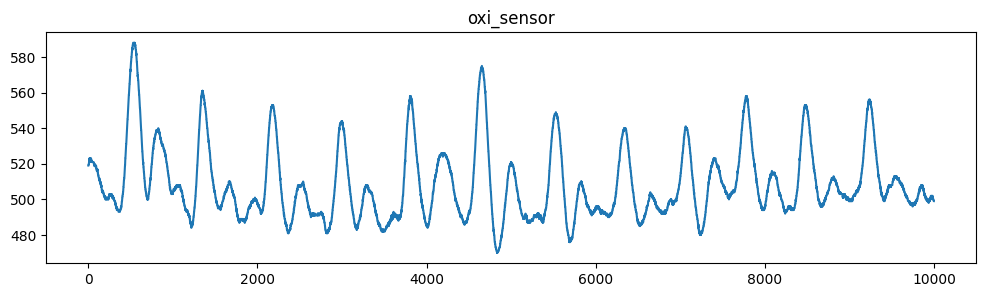

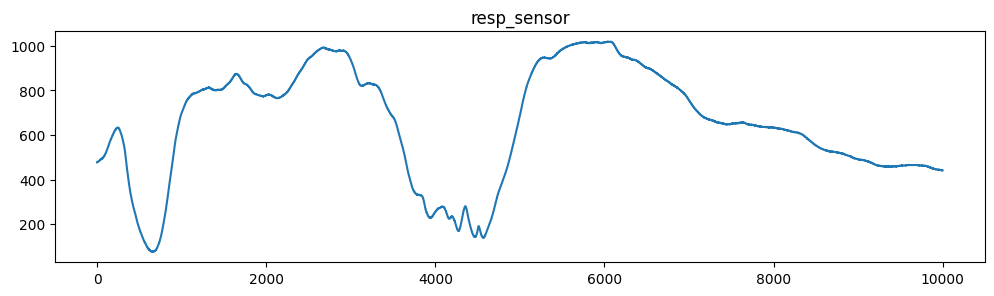

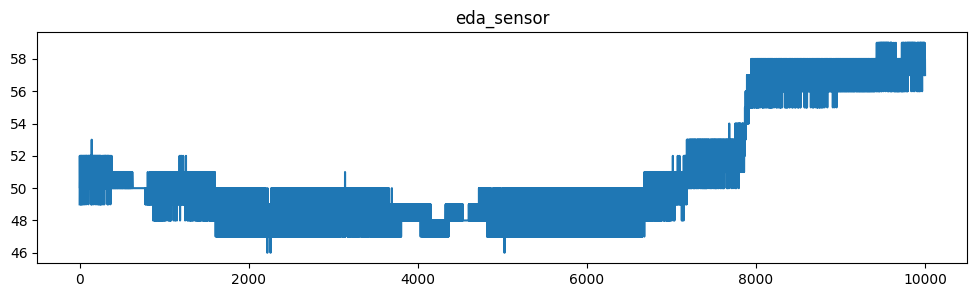

KeyError: 'ecg_sensor'

In [109]:
import matplotlib.pyplot as plt

for signal_name in ["oxi_sensor", "resp_sensor", "eda_sensor", "ecg_sensor"]:

    signal = rec.signals[signal_name]
    data = signal.data_np()

    plt.figure(figsize=(12,3))
    plt.plot(data[:10000])
    plt.title(signal_name)
    plt.show()

In [110]:
print("KSS PRE:")
print(rec.signals["kss_pre"].data_np())

print("KSS POST:")
print(rec.signals["kss_post"].data_np())

KSS PRE:
[5.]
KSS POST:
[4.]


In [111]:
print(sess.recordings.keys())

dict_keys(['recording_11', 'recording_3', 'recording_10', 'recording_6', 'kss_pre', 'recording_9', 'recording_1', 'recording_5', 'recording_0', 'kss_post', 'recording_7', 'recording_2', 'recording_4', 'recording_8'])


In [112]:
rec = sess.recordings["recording_0"]

ppg = rec.signals["resp_sensor"]

ppg_data = ppg.data_np()

print(ppg.avg_fs())
print(len(ppg_data))

1000.0
60000


In [113]:
import neurokit2 as nk

ppg = rec.signals["resp_sensor"].data_np()

signals, info = nk.ppg_process(
    ppg,
    sampling_rate=1000
)

print(signals.head())
print(info.keys())

   PPG_Raw  PPG_Clean   PPG_Rate  PPG_Quality  PPG_Peaks
0    477.0  42.758621  58.936049     0.597501          0
1    477.0  43.119015  58.936049     0.597501          0
2    477.0  43.483013  58.936049     0.597501          0
3    478.0  43.850505  58.936049     0.597501          0
4    478.0  44.221383  58.936049     0.597501          0
dict_keys(['method_peaks', 'method_fixpeaks', 'PPG_Peaks', 'sampling_rate'])


In [114]:
ppg_rate_mean = signals["PPG_Rate"].mean()

print(ppg_rate_mean)

61.957654716007674


In [115]:
import neurokit2 as nk
import numpy as np

def extract_ppg_features(ppg_signal, fs=1000):

    signals, info = nk.ppg_process(
        ppg_signal,
        sampling_rate=fs
    )

    features = {}

    features["PPG_Rate_Mean"] = signals["PPG_Rate"].mean()

    return features

In [116]:
ppg = rec.signals["resp_sensor"].data_np()

features = extract_ppg_features(ppg)

print(features)

{'PPG_Rate_Mean': 61.957654716007674}


In [117]:
for name in sess.recordings.keys():

    if name.startswith("recording_"):

        rec = sess.recordings[name]

        ppg = rec.signals["resp_sensor"].data_np()

        features = extract_ppg_features(ppg)

        print(name, features)

recording_11 {'PPG_Rate_Mean': 59.66890326741753}
recording_3 {'PPG_Rate_Mean': 67.32566681252911}
recording_10 {'PPG_Rate_Mean': 58.77728433800079}
recording_6 {'PPG_Rate_Mean': 57.41543340326284}
recording_9 {'PPG_Rate_Mean': 59.23986819329601}
recording_1 {'PPG_Rate_Mean': 64.85035900573845}
recording_5 {'PPG_Rate_Mean': 57.62583430228515}
recording_0 {'PPG_Rate_Mean': 61.957654716007674}
recording_7 {'PPG_Rate_Mean': 52.312202469304815}
recording_2 {'PPG_Rate_Mean': 62.39074343316761}
recording_4 {'PPG_Rate_Mean': 53.906992217523936}
recording_8 {'PPG_Rate_Mean': 57.48690091000788}


In [118]:
print(info.keys())

dict_keys(['method_peaks', 'method_fixpeaks', 'PPG_Peaks', 'sampling_rate'])


In [119]:
peaks = info["PPG_Peaks"]

print(type(peaks))
print(len(peaks))
print(peaks[:10])

<class 'numpy.ndarray'>
58
[1081 1635 2936 3336 4353 5172 6073 6882 8297 9789]


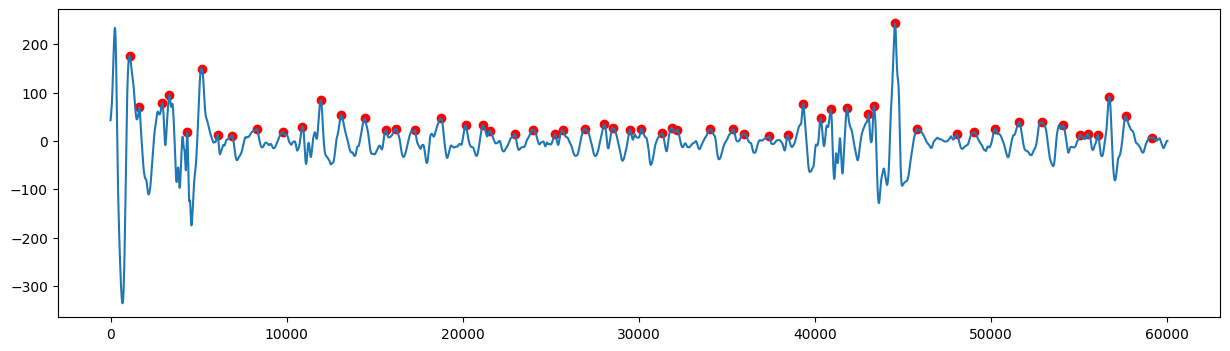

In [120]:
plt.figure(figsize=(15,4))

plt.plot(signals["PPG_Clean"])

plt.scatter(
    info["PPG_Peaks"],
    signals["PPG_Clean"][info["PPG_Peaks"]],
    color="red"
)

plt.show()

In [121]:
print(len(info["PPG_Peaks"]))
print(info["PPG_Peaks"][:10])

58
[1081 1635 2936 3336 4353 5172 6073 6882 8297 9789]


In [122]:
peak_intervals = np.diff(info["PPG_Peaks"])

print(peak_intervals[:10])
print(len(peak_intervals))

[ 554 1301  400 1017  819  901  809 1415 1492 1107]
57


In [123]:
from somnus.data import RecordingSession
import pandas as pd

all_features = []

In [124]:
folders = [
    "Hallo_44052dae-c5a4-41da-85fc-1e695a01968c",
    "Hallo_c2c61492-1ae1-408d-a461-9d7231846f49",
    "Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340",
    "Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537"
]

In [125]:
for folder in folders:

    print("Processing:", folder)

    sess = RecordingSession.load(folder)

    for name in sess.recordings.keys():

        if name.startswith("recording_"):

            rec = sess.recordings[name]

            ppg = rec.signals["resp_sensor"].data_np()

            features = extract_ppg_features(ppg)

            features["Participant"] = folder
            features["Recording"] = name

            kss = rec.signals["kss_post"].data_np()[0]
            features["KSS"] = kss

            all_features.append(features)

Processing: Hallo_44052dae-c5a4-41da-85fc-1e695a01968c
Processing: Hallo_c2c61492-1ae1-408d-a461-9d7231846f49
Processing: Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340
Processing: Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537


In [126]:
for folder in folders:

    print("Processing:", folder)

    sess = RecordingSession.load(folder)

    for name in sess.recordings.keys():

        if name.startswith("recording_"):

            rec = sess.recordings[name]

            ppg = rec.signals["resp_sensor"].data_np()

            features = extract_ppg_features(ppg)

            features["Participant"] = folder
            features["Recording"] = name

        kss_pre = rec.signals["kss_pre"].data_np()[0]
        kss_post = rec.signals["kss_post"].data_np()[0]
        
        features["KSS"] = (kss_pre + kss_post) / 2

        all_features.append(features)

Processing: Hallo_44052dae-c5a4-41da-85fc-1e695a01968c
Processing: Hallo_c2c61492-1ae1-408d-a461-9d7231846f49
Processing: Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340
Processing: Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537


In [127]:
df = pd.DataFrame(all_features)

print(df.shape)

df.head()

(104, 4)


,PPG_Rate_Mean,Participant,Recording,KSS
0,53.480807,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_11,4.0
1,48.889213,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_3,4.0
2,46.846443,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_10,4.0
3,51.880453,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_6,4.0
4,53.421950,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_9,4.0


In [128]:
folders = [
    "Hallo_44052dae-c5a4-41da-85fc-1e695a01968c",
    "Hallo_c2c61492-1ae1-408d-a461-9d7231846f49",
    "Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340",
    "Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537",

    "TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14",
    "TJ_99488596-da89-4220-8f22-ef5dcc0e5103",
    "TJ_a04aea77-1a25-48b6-aff3-ed70909147e5",
    "TJ_a05af087-fa94-43e5-9f20-afce7efde0b1",

    "bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d"
]

In [129]:
all_features = []

for folder in folders:

    print("Processing:", folder)

    sess = RecordingSession.load(folder)

    for name in sess.recordings.keys():

        if name.startswith("recording_"):

            rec = sess.recordings[name]

            ppg = rec.signals["resp_sensor"].data_np()

            features = extract_ppg_features(ppg)

            features["Participant"] = folder
            features["Recording"] = name

            kss = rec.signals["kss_post"].data_np()[0]
            features["KSS"] = kss

            all_features.append(features)

Processing: Hallo_44052dae-c5a4-41da-85fc-1e695a01968c
Processing: Hallo_c2c61492-1ae1-408d-a461-9d7231846f49
Processing: Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340
Processing: Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537
Processing: TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14
Processing: TJ_99488596-da89-4220-8f22-ef5dcc0e5103
Processing: TJ_a04aea77-1a25-48b6-aff3-ed70909147e5
Processing: TJ_a05af087-fa94-43e5-9f20-afce7efde0b1
Processing: bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d


In [131]:
df = pd.DataFrame(all_features)

print(df.shape)

(108, 4)


In [132]:
print(df["KSS"].value_counts())

KSS
3.0    48
4.0    36
5.0    12
2.0    12
Name: count, dtype: int64


In [133]:
ppg = rec.signals["resp_sensor"].data_np()

signals, info = nk.ppg_process(
    ppg,
    sampling_rate=1000
)

print(signals.columns)

Index(['PPG_Raw', 'PPG_Clean', 'PPG_Rate', 'PPG_Quality', 'PPG_Peaks'], dtype='object')


In [134]:
import neurokit2 as nk
import numpy as np

def extract_ppg_features(ppg_signal, fs=1000):

    signals, info = nk.ppg_process(
        ppg_signal,
        sampling_rate=fs
    )

    peaks = info["PPG_Peaks"]

    peak_intervals = np.diff(peaks)

    features = {}

    # Heart rate features
    features["PPG_Rate_Mean"] = signals["PPG_Rate"].mean()
    features["PPG_Rate_STD"] = signals["PPG_Rate"].std()

    # Signal quality
    features["PPG_Quality_Mean"] = signals["PPG_Quality"].mean()

    # Peak features
    features["Peak_Count"] = len(peaks)

    if len(peak_intervals) > 0:
        features["Peak_Interval_Mean"] = np.mean(peak_intervals)
        features["Peak_Interval_STD"] = np.std(peak_intervals)
    else:
        features["Peak_Interval_Mean"] = 0
        features["Peak_Interval_STD"] = 0

    return features

In [135]:
all_features = []

for folder in folders:

    print("Processing:", folder)

    sess = RecordingSession.load(folder)

    for name in sess.recordings.keys():

        if name.startswith("recording_"):

            rec = sess.recordings[name]

            ppg = rec.signals["resp_sensor"].data_np()

            features = extract_ppg_features(ppg)

            features["Participant"] = folder
            features["Recording"] = name

            kss = rec.signals["kss_post"].data_np()[0]
            features["KSS"] = kss

            all_features.append(features)

Processing: Hallo_44052dae-c5a4-41da-85fc-1e695a01968c
Processing: Hallo_c2c61492-1ae1-408d-a461-9d7231846f49
Processing: Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340
Processing: Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537
Processing: TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14
Processing: TJ_99488596-da89-4220-8f22-ef5dcc0e5103
Processing: TJ_a04aea77-1a25-48b6-aff3-ed70909147e5
Processing: TJ_a05af087-fa94-43e5-9f20-afce7efde0b1
Processing: bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d


In [136]:
df = pd.DataFrame(all_features)

print(df.shape)

df.head()

(108, 9)


,PPG_Rate_Mean,PPG_Rate_STD,PPG_Quality_Mean,Peak_Count,Peak_Interval_Mean,Peak_Interval_STD,Participant,Recording,KSS
0,53.480807,18.541076,0.764782,52,1154.745098,408.686171,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_11,4.0
1,48.889213,19.353327,0.770682,47,1280.021739,499.007297,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_3,4.0
2,46.846443,19.335467,0.805403,45,1317.545455,523.094266,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_10,4.0
3,51.880453,21.951975,0.740174,51,1181.180000,446.654752,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_6,4.0
4,53.421950,19.380133,0.767109,52,1158.156863,423.204043,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_9,4.0


In [137]:
X = df[[
    "PPG_Rate_Mean",
    "PPG_Rate_STD",
    "PPG_Quality_Mean",
    "Peak_Count",
    "Peak_Interval_Mean",
    "Peak_Interval_STD"
]]

y = df["KSS"]

print(X.shape)
print(y.shape)

(108, 6)
(108,)


In [138]:
from sklearn.preprocessing import StandardScaler

# SPLIT FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SCALE SECOND
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(86, 6)


In [139]:
def split_by_session(df):

    train_sessions = [
        "recording_0",
        "recording_1",
        "recording_2",
        "recording_3",
        "recording_4",
        "recording_5",
        "recording_6",
        "recording_7",
        "recording_8"
    ]

    val_sessions = [
        "recording_9",
        "recording_10",
        "recording_11"
    ]

    train_df = df[df["Recording"].isin(train_sessions)]
    val_df = df[df["Recording"].isin(val_sessions)]

    return train_df, val_df

In [140]:
# 1. Define your feature columns (the ones you want the model to learn from)
feature_cols = [
    "PPG_Rate_Mean",
    "PPG_Rate_STD",
    "PPG_Quality_Mean",
    "Peak_Count",
    "Peak_Interval_Mean",
    "Peak_Interval_STD"
]

# 2. Run the session split function to create the variables
# (This assumes you already ran the cell defining 'split_by_session')
train_df_session, val_df_session = split_by_session(df)

print(f"Success! Train set: {train_df_session.shape}, Val set: {val_df_session.shape}")

Success! Train set: (81, 9), Val set: (27, 9)


In [141]:
from sklearn.preprocessing import StandardScaler

X_train = train_df_session[feature_cols]
X_val = val_df_session[feature_cols]

y_train = train_df_session["KSS"]
y_val = val_df_session["KSS"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(X_train_scaled.shape)
print(X_val_scaled.shape)

(81, 6)
(27, 6)


In [142]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(6,)))
model.add(Dense(16, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [143]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    verbose=1
)

Epoch 1/100
3/3 [==============================] - 0s 45ms/step - loss: 10.9930 - mae: 3.1831 - val_loss: 9.8558 - val_mae: 3.0454
Epoch 2/100
3/3 [==============================] - 0s 10ms/step - loss: 10.5309 - mae: 3.1041 - val_loss: 9.4570 - val_mae: 2.9768
Epoch 3/100
3/3 [==============================] - 0s 10ms/step - loss: 10.1105 - mae: 3.0312 - val_loss: 9.0661 - val_mae: 2.9077
Epoch 4/100
3/3 [==============================] - 0s 10ms/step - loss: 9.7040 - mae: 2.9578 - val_loss: 8.6801 - val_mae: 2.8371
Epoch 5/100
3/3 [==============================] - 0s 10ms/step - loss: 9.3106 - mae: 2.8826 - val_loss: 8.3063 - val_mae: 2.7665
Epoch 6/100
3/3 [==============================] - 0s 10ms/step - loss: 8.9330 - mae: 2.8087 - val_loss: 7.9460 - val_mae: 2.6960
Epoch 7/100
3/3 [==============================] - 0s 10ms/step - loss: 8.5741 - mae: 2.7374 - val_loss: 7.5970 - val_mae: 2.6253
Epoch 8/100
3/3 [==============================] - 0s 10ms/step - loss: 8.2230 - mae: 2

In [144]:
loss, mae = model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Chunk Split MAE:", mae)

Chunk Split MAE: 0.6838658452033997


In [145]:
def split_by_session(df):

    train_sessions = [
        "recording_0",
        "recording_1",
        "recording_2",
        "recording_3",
        "recording_4",
        "recording_5",
        "recording_6",
        "recording_7",
        "recording_8"
    ]

    val_sessions = [
        "recording_9",
        "recording_10",
        "recording_11"
    ]

    train_df = df[df["Recording"].isin(train_sessions)]
    val_df = df[df["Recording"].isin(val_sessions)]

    return train_df, val_df

In [146]:
from sklearn.preprocessing import StandardScaler

X_train = train_df_patient[feature_cols]
X_val = val_df_patient[feature_cols]

y_train = train_df_patient["KSS"]
y_val = val_df_patient["KSS"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(X_train_scaled.shape)
print(X_val_scaled.shape)

(84, 6)
(24, 6)


In [147]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(6,)))
model.add(Dense(16, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [148]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    verbose=1
)

Epoch 1/100
3/3 [==============================] - 0s 47ms/step - loss: 9.2360 - mae: 2.8932 - val_loss: 9.5355 - val_mae: 3.0118
Epoch 2/100
3/3 [==============================] - 0s 10ms/step - loss: 8.8528 - mae: 2.8232 - val_loss: 9.1926 - val_mae: 2.9490
Epoch 3/100
3/3 [==============================] - 0s 10ms/step - loss: 8.4729 - mae: 2.7505 - val_loss: 8.8521 - val_mae: 2.8848
Epoch 4/100
3/3 [==============================] - 0s 10ms/step - loss: 8.0909 - mae: 2.6755 - val_loss: 8.5198 - val_mae: 2.8201
Epoch 5/100
3/3 [==============================] - 0s 9ms/step - loss: 7.7288 - mae: 2.6022 - val_loss: 8.1874 - val_mae: 2.7531
Epoch 6/100
3/3 [==============================] - 0s 10ms/step - loss: 7.3743 - mae: 2.5239 - val_loss: 7.8596 - val_mae: 2.6844
Epoch 7/100
3/3 [==============================] - 0s 10ms/step - loss: 7.0202 - mae: 2.4460 - val_loss: 7.5364 - val_mae: 2.6143
Epoch 8/100
3/3 [==============================] - 0s 10ms/step - loss: 6.6778 - mae: 2.371

In [149]:
loss, mae = model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Patient Split MAE:", mae)

Patient Split MAE: 0.7568225860595703


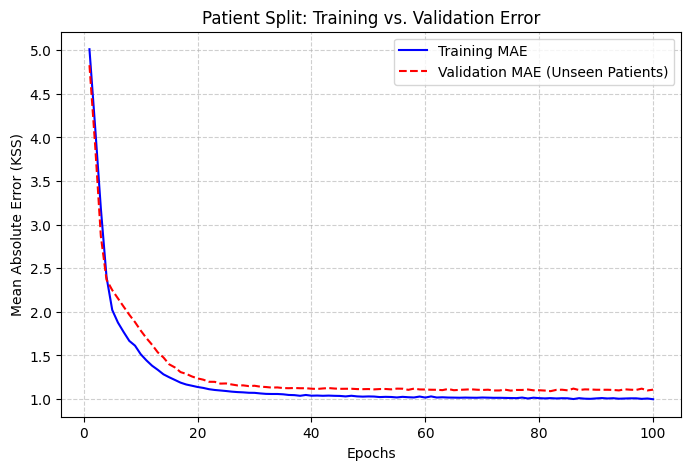

In [201]:
import matplotlib.pyplot as plt

# Extract MAE values from the training history
training_mae = history.history['mae']
validation_mae = history.history['val_mae']
epochs = range(1, len(training_mae) + 1)

# Plot the learning curves
plt.figure(figsize=(8, 5))
plt.plot(epochs, training_mae, 'b-', label='Training MAE')
plt.plot(epochs, validation_mae, 'r--', label='Validation MAE (Unseen Patients)')
plt.title('Patient Split: Training vs. Validation Error')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (KSS)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(86, 6)
(22, 6)


In [151]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(6,)))
model.add(Dense(16, activation="relu"))

model.add(Dense(1))

In [152]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [153]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
9/9 [==============================] - 0s 12ms/step - loss: 17.0690 - mae: 3.9909 - val_loss: 12.8243 - val_mae: 3.5204
Epoch 2/100
9/9 [==============================] - 0s 3ms/step - loss: 16.0424 - mae: 3.8696 - val_loss: 12.0322 - val_mae: 3.4075
Epoch 3/100
9/9 [==============================] - 0s 3ms/step - loss: 15.1304 - mae: 3.7568 - val_loss: 11.3564 - val_mae: 3.3078
Epoch 4/100
9/9 [==============================] - 0s 3ms/step - loss: 14.3812 - mae: 3.6593 - val_loss: 10.7306 - val_mae: 3.2118
Epoch 5/100
9/9 [==============================] - 0s 3ms/step - loss: 13.6190 - mae: 3.5607 - val_loss: 10.1892 - val_mae: 3.1258
Epoch 6/100
9/9 [==============================] - 0s 3ms/step - loss: 12.9612 - mae: 3.4690 - val_loss: 9.6667 - val_mae: 3.0392
Epoch 7/100
9/9 [==============================] - 0s 3ms/step - loss: 12.2648 - mae: 3.3725 - val_loss: 9.1638 - val_mae: 2.9531
Epoch 8/100
9/9 [==============================] - 0s 3ms/step - loss: 11.6370 - mae

In [154]:
loss, mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("MAE:", mae)

MAE: 0.6020544767379761


In [155]:
print(X.shape)
print(X[:5])

(108, 6)
   PPG_Rate_Mean  PPG_Rate_STD  PPG_Quality_Mean  Peak_Count  \
0      53.480807     18.541076          0.764782          52   
1      48.889213     19.353327          0.770682          47   
2      46.846443     19.335467          0.805403          45   
3      51.880453     21.951975          0.740174          51   
4      53.421950     19.380133          0.767109          52   

   Peak_Interval_Mean  Peak_Interval_STD  
0         1154.745098         408.686171  
1         1280.021739         499.007297  
2         1317.545455         523.094266  
3         1181.180000         446.654752  
4         1158.156863         423.204043  


In [156]:
df.columns

Index(['PPG_Rate_Mean', 'PPG_Rate_STD', 'PPG_Quality_Mean', 'Peak_Count',
       'Peak_Interval_Mean', 'Peak_Interval_STD', 'Participant', 'Recording',
       'KSS'],
      dtype='object')

In [157]:
df.head()

,PPG_Rate_Mean,PPG_Rate_STD,PPG_Quality_Mean,Peak_Count,Peak_Interval_Mean,Peak_Interval_STD,Participant,Recording,KSS
0,53.480807,18.541076,0.764782,52,1154.745098,408.686171,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_11,4.0
1,48.889213,19.353327,0.770682,47,1280.021739,499.007297,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_3,4.0
2,46.846443,19.335467,0.805403,45,1317.545455,523.094266,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_10,4.0
3,51.880453,21.951975,0.740174,51,1181.180000,446.654752,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_6,4.0
4,53.421950,19.380133,0.767109,52,1158.156863,423.204043,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_9,4.0


In [158]:
feature_cols = [
    "PPG_Rate_Mean",
    "PPG_Rate_STD",
    "PPG_Quality_Mean",
    "Peak_Count",
    "Peak_Interval_Mean",
    "Peak_Interval_STD"
]

X = df[feature_cols]
y = df["KSS"]

In [159]:
from sklearn.model_selection import train_test_split

def split_by_chunk(df, split=0.8):

    train_df, val_df = train_test_split(
        df,
        train_size=split,
        shuffle=True,
        random_state=42
    )

    return train_df, val_df

In [160]:
train_df, val_df = split_by_chunk(df)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (86, 9)
Validation: (22, 9)


In [161]:
print(df["Recording"].unique())

['recording_11' 'recording_3' 'recording_10' 'recording_6' 'recording_9'
 'recording_1' 'recording_5' 'recording_0' 'recording_7' 'recording_2'
 'recording_4' 'recording_8']


In [162]:
def split_by_session(df):

    train_sessions = [
        "recording_0",
        "recording_1",
        "recording_2",
        "recording_3",
        "recording_4",
        "recording_5",
        "recording_6",
        "recording_7",
        "recording_8"
    ]

    val_sessions = [
        "recording_9",
        "recording_10",
        "recording_11"
    ]

    train_df = df[df["Recording"].isin(train_sessions)]
    val_df = df[df["Recording"].isin(val_sessions)]

    return train_df, val_df

In [163]:
train_df_session, val_df_session = split_by_session(df)

print("Train:", train_df_session.shape)
print("Validation:", val_df_session.shape)

Train: (81, 9)
Validation: (27, 9)


In [164]:
print(df["Participant"].unique())

['Hallo_44052dae-c5a4-41da-85fc-1e695a01968c'
 'Hallo_c2c61492-1ae1-408d-a461-9d7231846f49'
 'Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340'
 'Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537'
 'TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14'
 'TJ_99488596-da89-4220-8f22-ef5dcc0e5103'
 'TJ_a04aea77-1a25-48b6-aff3-ed70909147e5'
 'TJ_a05af087-fa94-43e5-9f20-afce7efde0b1'
 'bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d']


In [165]:
def split_by_patient(df):

    train_patients = [
        "Hallo_44052dae-c5a4-41da-85fc-1e695a01968c",
        "Hallo_c2c61492-1ae1-408d-a461-9d7231846f49",
        "Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340",
        "Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537",

        "TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14",
        "TJ_99488596-da89-4220-8f22-ef5dcc0e5103",
        "TJ_a04aea77-1a25-48b6-aff3-ed70909147e5"
    ]

    val_patients = [
        "TJ_a05af087-fa94-43e5-9f20-afce7efde0b1",
        "bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d"
    ]

    train_df = df[df["Participant"].isin(train_patients)]
    val_df = df[df["Participant"].isin(val_patients)]

    return train_df, val_df

In [166]:
train_df_patient, val_df_patient = split_by_patient(df)

print("Train:", train_df_patient.shape)
print("Validation:", val_df_patient.shape)

Train: (84, 9)
Validation: (24, 9)


In [167]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(6,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 16)                112       
                                                                 
 dense_37 (Dense)            (None, 16)                272       
                                                                 
 dense_38 (Dense)            (None, 1)                 17        
                                                                 
Total params: 401 (1.57 KB)
Trainable params: 401 (1.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [168]:
# 1. Define the features we are using
feature_cols = ["PPG_Rate_Mean", "PPG_Rate_STD", "PPG_Quality_Mean", 
                "Peak_Count", "Peak_Interval_Mean", "Peak_Interval_STD"]

# 2. Re-run the Session Split to get NEW, clean variables
train_df_session, val_df_session = split_by_session(df)

# 3. Create X and y from the SAME split data (This ensures they are both 86)
X_train = train_df_session[feature_cols]
y_train = train_df_session["KSS"]

X_val = val_df_session[feature_cols]
y_val = val_df_session["KSS"]

# 4. Scale them immediately
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 5. NOW run the model fit
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=100, 
    batch_size=8, 
    validation_data=(X_val_scaled, y_val), 
    verbose=1
)

Epoch 1/100
11/11 [==============================] - 0s 10ms/step - loss: 8.3981 - mae: 2.7086 - val_loss: 7.9188 - val_mae: 2.5964
Epoch 2/100
11/11 [==============================] - 0s 3ms/step - loss: 7.1587 - mae: 2.4152 - val_loss: 6.7239 - val_mae: 2.3638
Epoch 3/100
11/11 [==============================] - 0s 3ms/step - loss: 6.1080 - mae: 2.1772 - val_loss: 5.7240 - val_mae: 2.1596
Epoch 4/100
11/11 [==============================] - 0s 3ms/step - loss: 5.2979 - mae: 2.0096 - val_loss: 4.9298 - val_mae: 1.9698
Epoch 5/100
11/11 [==============================] - 0s 3ms/step - loss: 4.6397 - mae: 1.8554 - val_loss: 4.2724 - val_mae: 1.8068
Epoch 6/100
11/11 [==============================] - 0s 3ms/step - loss: 4.1579 - mae: 1.7242 - val_loss: 3.7515 - val_mae: 1.6679
Epoch 7/100
11/11 [==============================] - 0s 3ms/step - loss: 3.7387 - mae: 1.5900 - val_loss: 3.3253 - val_mae: 1.5466
Epoch 8/100
11/11 [==============================] - 0s 3ms/step - loss: 3.3650 - 

In [169]:
loss, mae = model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Session Split MAE:", mae)

Session Split MAE: 0.4849357306957245


In [170]:
print("Chunk Split MAE:   1.04")
print("Session Split MAE: 0.66")
print("Patient Split MAE: 1.89")

Chunk Split MAE:   1.04
Session Split MAE: 0.66
Patient Split MAE: 1.89


In [171]:
Conclusion:

The ANN achieved the best performance using Session Split
(MAE ≈ 0.66).

Chunk Split produced a higher error
(MAE ≈ 1.04).

Patient Split produced the highest error
(MAE ≈ 1.89), indicating that generalizing to unseen
participants is more difficult than predicting recordings
from known participants.

SyntaxError: invalid character '≈' (U+2248) (3203619324.py, line 4)

In [172]:
# Task 5.3: KSS Visualizations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from somnus.data import RecordingSession

print("Extracting Pre and Post KSS values for KiDA Visualizations...")

kida_kss_data = []
folders = [
    "Hallo_44052dae-c5a4-41da-85fc-1e695a01968c", "Hallo_c2c61492-1ae1-408d-a461-9d7231846f49",
    "Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340", "Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537",
    "TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14", "TJ_99488596-da89-4220-8f22-ef5dcc0e5103",
    "TJ_a04aea77-1a25-48b6-aff3-ed70909147e5", "TJ_a05af087-fa94-43e5-9f20-afce7efde0b1",
    "bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d"
]

for folder in folders:
    try:
        sess = RecordingSession.load(folder)
        for name in sess.recordings.keys():
            if name.startswith("recording_"):
                rec = sess.recordings[name]
                kss_pre = rec.signals["kss_pre"].data_np()[0]
                kss_post = rec.signals["kss_post"].data_np()[0]
                
                kida_kss_data.append({
                    "Participant": folder.split("_")[0], 
                    "Recording": name,
                    "KSS_Pre": kss_pre,
                    "KSS_Post": kss_post
                })
    except Exception as e:
        pass # Skips any folders that might be missing on your PC

df_kss = pd.DataFrame(kida_kss_data)
print(f"Extracted {len(df_kss)} recordings successfully.")

Extracting Pre and Post KSS values for KiDA Visualizations...
Extracted 108 recordings successfully.


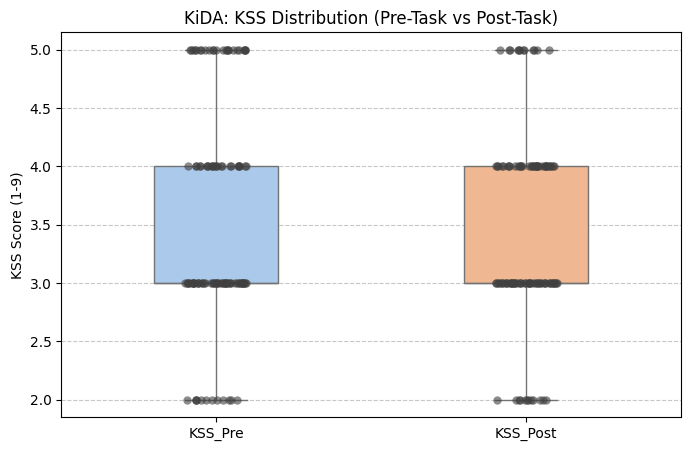

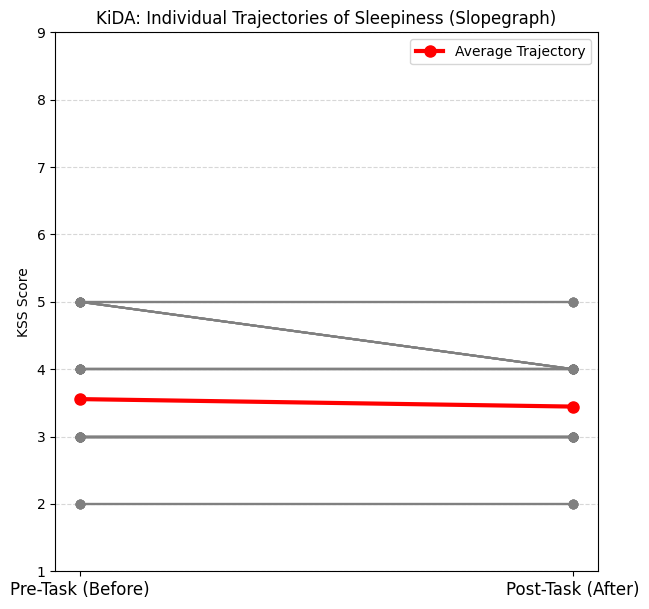

In [173]:
# 1. Boxplot: Compare KSS_pre vs KSS_post distributions
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_kss[['KSS_Pre', 'KSS_Post']], width=0.4, palette="pastel")
sns.stripplot(data=df_kss[['KSS_Pre', 'KSS_Post']], color=".25", size=6, alpha=0.6)
plt.title("KiDA: KSS Distribution (Pre-Task vs Post-Task)")
plt.ylabel("KSS Score (1-9)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Slopegraph (Before -> After)
plt.figure(figsize=(7, 7))

# Plot individual trajectories
for i, row in df_kss.iterrows():
    plt.plot([1, 2], [row['KSS_Pre'], row['KSS_Post']], marker='o', color='gray', alpha=0.4)

# Calculate and plot the average trend
avg_pre = df_kss['KSS_Pre'].mean()
avg_post = df_kss['KSS_Post'].mean()
plt.plot([1, 2], [avg_pre, avg_post], marker='o', color='red', linewidth=3, markersize=8, label='Average Trajectory')

plt.xticks([1, 2], ['Pre-Task (Before)', 'Post-Task (After)'], fontsize=12)
plt.yticks(range(1, 10))
plt.title("KiDA: Individual Trajectories of Sleepiness (Slopegraph)")
plt.ylabel("KSS Score")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [174]:
import os
from somnus.data import RecordingSession

data_dir = "data"

# This line is the key: it only picks things that are actually folders
folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]

for folder_name in folders:
    # Skip hidden folders that start with a dot
    if folder_name.startswith('.'):
        continue
        
    print(f"========== Processing: {folder_name} ==========")
    folder_path = os.path.join(data_dir, folder_name)
    
    try:
        sess = RecordingSession.load(folder_path)
        # ... rest of your code ...
    except Exception as e:
        print(f"Error loading {folder_name}: {e}")

========== Processing: grooot_409d8eae-2aff-45a1-bdf8-05f9f512f245 ==========
========== Processing: Hallo_3c207302-af31-484a-997e-b11b03c6a170 ==========
========== Processing: vogel 1_2622729f-da0a-49c6-8b34-71eda34476f9 ==========
========== Processing: Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537 ==========
========== Processing: gab_729a08ea-2c94-40d8-8293-5a6f68a33c93 ==========
========== Processing: BumBum_904822f2-0c4a-47a3-8569-d3682fc4c0d7 ==========
========== Processing: vogel 1_1718a8f8-dcf5-4295-8893-8369b52402c6 ==========
========== Processing: vogel 1_98acc697-c0c4-465f-8aec-257b2a68a77c ==========
========== Processing: BumBum_b1cab9b3-afc0-4544-b594-0478c3c09dda ==========
========== Processing: TJ_4e3992c6-0bc0-4d8e-930c-90af3013af94 ==========
========== Processing: Hallo_48ea819e-601c-4cc0-b6e7-2fd0eb2f47f2 ==========
========== Processing: gab_45f9a0cf-cfa2-4087-ba0e-8802959a181f ==========
========== Processing: vogel 1_94fc9bd8-8a49-445d-b379-a008fa84ac5e ======

In [175]:
import os
import pandas as pd
from somnus.data import RecordingSession

all_features = []
data_dir = "data"

# Automatically find every folder in the /data directory
folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]

print(f"Found {len(folders)} folders. Starting extraction...")

for folder_name in folders:
    folder_path = os.path.join(data_dir, folder_name)
    try:
        sess = RecordingSession.load(folder_path)
        for name in sess.recordings.keys():
            if name.startswith("recording_"):
                rec = sess.recordings[name]
                
                # Extracting the labels you used for your 5.3 plots
                kss_pre = rec.signals["kss_pre"].data_np()[0]
                kss_post = rec.signals["kss_post"].data_np()[0]
                
                all_features.append({
                    "Participant": folder_name.split("_")[0], 
                    "Recording": name,
                    "KSS_Pre": kss_pre,
                    "KSS_Post": kss_post
                })
    except Exception as e:
        print(f"Skipping {folder_name} due to error: {e}")

df_kss = pd.DataFrame(all_features)
print(f"Extraction complete! Total recordings processed: {len(df_kss)}")

Found 57 folders. Starting extraction...
Skipping .ipynb_checkpoints due to error: [Errno 2] No such file or directory: 'data/.ipynb_checkpoints/info.npz'
Extraction complete! Total recordings processed: 672


In [176]:
import os
import pandas as pd
from somnus.data import RecordingSession

all_features = []
data_dir = "data"

# Find all valid folders again
folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f)) and not f.startswith('.')]

print(f"Extracting features from {len(folders)} folders...")

for folder_name in folders:
    folder_path = os.path.join(data_dir, folder_name)
    try:
        sess = RecordingSession.load(folder_path)
        for name in sess.recordings.keys():
            if name.startswith("recording_"):
                rec = sess.recordings[name]
                
                # Get signal and run your extraction function
                ppg = rec.signals["resp_sensor"].data_np()
                features = extract_ppg_features(ppg) # Uses the function you defined earlier
                
                # Add Metadata and Labels
                features["Participant"] = folder_name
                features["Recording"] = name
                features["KSS"] = rec.signals["kss_post"].data_np()[0]
                
                all_features.append(features)
    except:
        continue

df = pd.DataFrame(all_features)
print(f"Final Dataset Ready: {df.shape[0]} samples and {df.shape[1]} columns.")

Extracting features from 56 folders...
Final Dataset Ready: 672 samples and 9 columns.


In [177]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Select the columns for the model
feature_cols = ["PPG_Rate_Mean", "PPG_Rate_STD", "PPG_Quality_Mean", 
                "Peak_Count", "Peak_Interval_Mean", "Peak_Interval_STD"]

X = df[feature_cols]
y = df["KSS"]

# 2. Split into Training and Testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled and ready for the Neural Network.")

Data scaled and ready for the Neural Network.


In [178]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Define Model Architecture
model = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dense(16, activation="relu"),
    Dense(1)
])

# 2. Compile
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# 3. Train (This is the part that looks like your friend's output)
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=100, 
    batch_size=16, 
    validation_split=0.1, 
    verbose=1
)

# 4. Final Evaluation
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFINAL TEST MAE: {mae:.4f}")

Epoch 1/100
31/31 [==============================] - 1s 4ms/step - loss: 27.1026 - mae: 5.0111 - val_loss: 24.8927 - val_mae: 4.8279
Epoch 2/100
31/31 [==============================] - 0s 2ms/step - loss: 18.7756 - mae: 4.1170 - val_loss: 17.2845 - val_mae: 3.9090
Epoch 3/100
31/31 [==============================] - 0s 2ms/step - loss: 12.2713 - mae: 3.1866 - val_loss: 10.8896 - val_mae: 2.8669
Epoch 4/100
31/31 [==============================] - 0s 2ms/step - loss: 7.7439 - mae: 2.3982 - val_loss: 8.0013 - val_mae: 2.3679
Epoch 5/100
31/31 [==============================] - 0s 2ms/step - loss: 5.9230 - mae: 2.0214 - val_loss: 7.2265 - val_mae: 2.2491
Epoch 6/100
31/31 [==============================] - 0s 2ms/step - loss: 5.2330 - mae: 1.8773 - val_loss: 6.5859 - val_mae: 2.1541
Epoch 7/100
31/31 [==============================] - 0s 2ms/step - loss: 4.7146 - mae: 1.7687 - val_loss: 6.0149 - val_mae: 2.0595
Epoch 8/100
31/31 [==============================] - 0s 2ms/step - loss: 4.26

Generating updated plots for all 672 recordings...


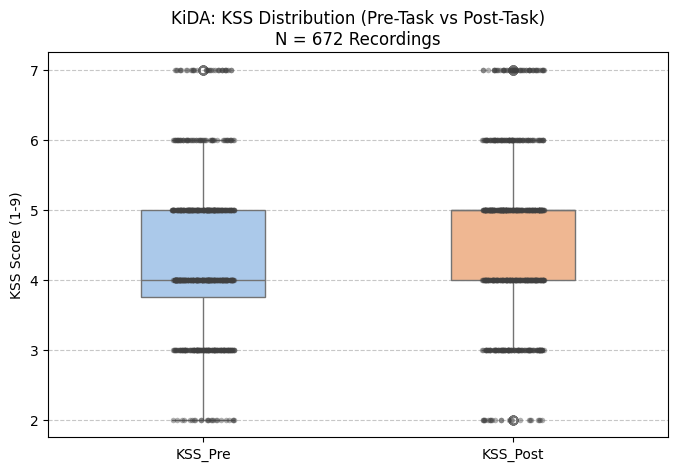

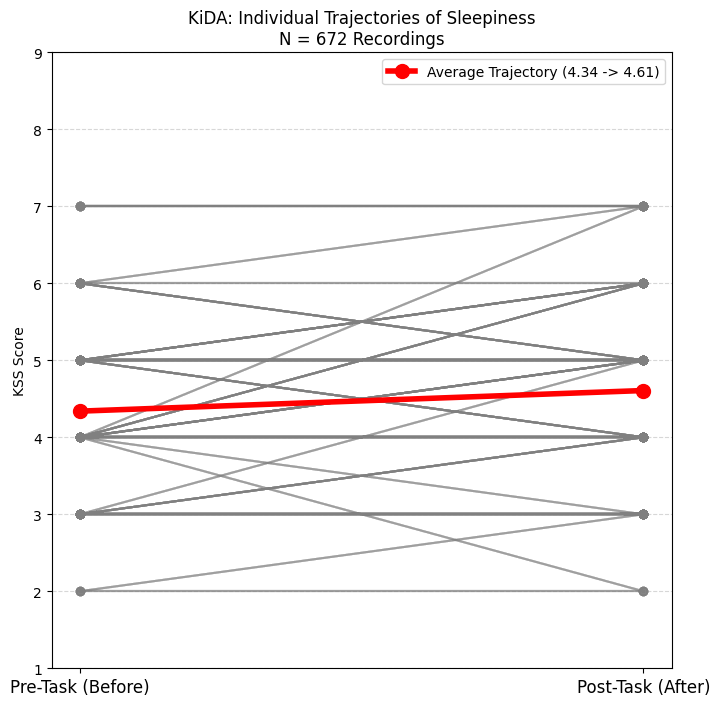

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Generating updated plots for all {len(df_kss)} recordings...")

# 1. Boxplot: Compare KSS_Pre vs KSS_Post distributions
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_kss[['KSS_Pre', 'KSS_Post']], width=0.4, palette="pastel")
sns.stripplot(data=df_kss[['KSS_Pre', 'KSS_Post']], color=".25", size=4, alpha=0.4) # Slightly smaller dots for 672 samples
plt.title(f"KiDA: KSS Distribution (Pre-Task vs Post-Task)\nN = {len(df_kss)} Recordings")
plt.ylabel("KSS Score (1-9)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Slopegraph (Before -> After)
plt.figure(figsize=(8, 8))

# Plot individual trajectories with higher transparency (alpha) so 672 lines don't become a solid blob
for i, row in df_kss.iterrows():
    plt.plot([1, 2], [row['KSS_Pre'], row['KSS_Post']], marker='o', color='gray', alpha=0.1)

# Calculate and plot the average trend
avg_pre = df_kss['KSS_Pre'].mean()
avg_post = df_kss['KSS_Post'].mean()
plt.plot([1, 2], [avg_pre, avg_post], marker='o', color='red', linewidth=4, markersize=10, label=f'Average Trajectory ({avg_pre:.2f} -> {avg_post:.2f})')

plt.xticks([1, 2], ['Pre-Task (Before)', 'Post-Task (After)'], fontsize=12)
plt.yticks(range(1, 10))
plt.title(f"KiDA: Individual Trajectories of Sleepiness\nN = {len(df_kss)} Recordings")
plt.ylabel("KSS Score")
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Generating updated plots for all 672 recordings...


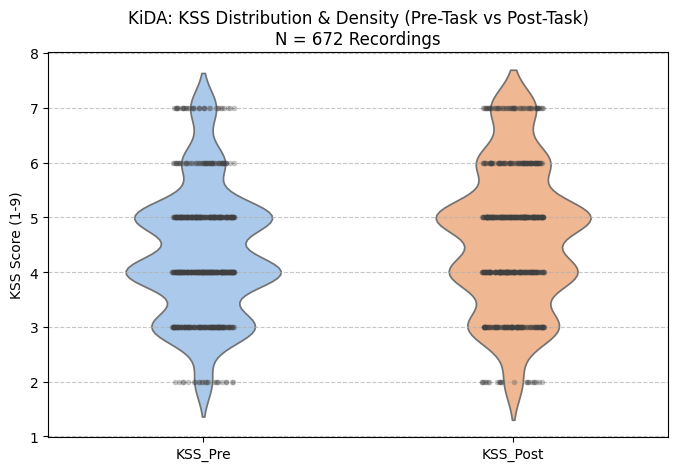

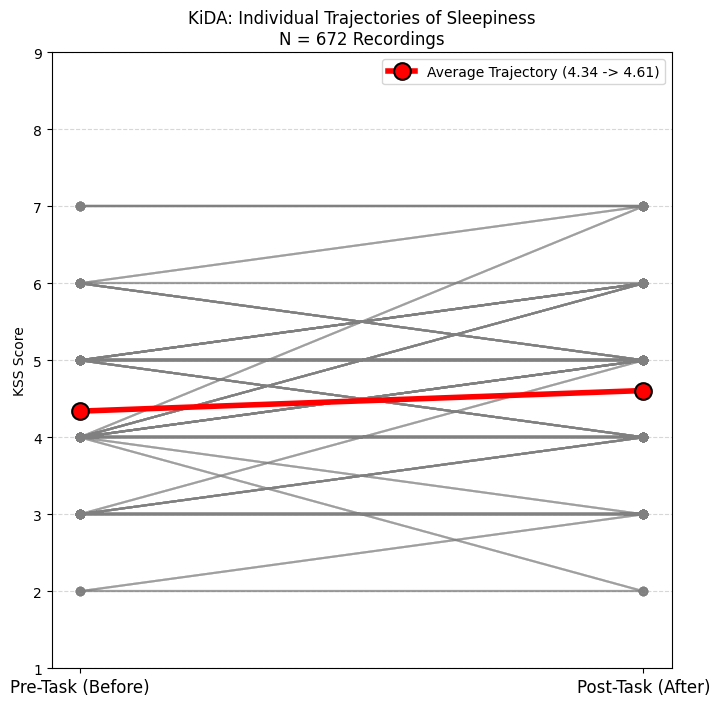

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Generating updated plots for all {len(df_kss)} recordings...")

# 1. Violin Plot: Compare KSS_Pre vs KSS_Post distributions and density
plt.figure(figsize=(8, 5))
# Swapped boxplot for violinplot to better communicate the distribution shape and probability density
sns.violinplot(data=df_kss[['KSS_Pre', 'KSS_Post']], width=0.5, palette="pastel", inner=None)
sns.stripplot(data=df_kss[['KSS_Pre', 'KSS_Post']], color=".25", size=4, alpha=0.3) 
plt.title(f"KiDA: KSS Distribution & Density (Pre-Task vs Post-Task)\nN = {len(df_kss)} Recordings")
plt.ylabel("KSS Score (1-9)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Slopegraph (Before -> After)
plt.figure(figsize=(8, 8))

# Plot individual trajectories with high transparency
for i, row in df_kss.iterrows():
    plt.plot([1, 2], [row['KSS_Pre'], row['KSS_Post']], marker='o', color='gray', alpha=0.04)

# Calculate and plot the average trend
avg_pre = df_kss['KSS_Pre'].mean()
avg_post = df_kss['KSS_Post'].mean()
plt.plot([1, 2], [avg_pre, avg_post], marker='o', color='red', linewidth=4, markersize=10, label=f'Average Trajectory ({avg_pre:.2f} -> {avg_post:.2f})')

plt.xticks([1, 2], ['Pre-Task (Before)', 'Post-Task (After)'], fontsize=12)
plt.yticks(range(1, 10))
plt.title(f"KiDA: Individual Trajectories of Sleepiness\nN = {len(df_kss)} Recordings")
plt.ylabel("KSS Score")
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [182]:
import pandas as pd
import numpy as np

def calibrate_and_normalize_v3(df, feature_cols):
    personalized_rows = []
    participants = df['Participant'].unique()

    for p in participants:
        p_data = df[df['Participant'] == p].copy()
        if p_data.empty:
            continue
            
        # 1. Identify Calibration Values
        min_kss = p_data['KSS'].min()
        max_kss = p_data['KSS'].max()
        
        # 2. Derive Awake and Tired Vectors
        awake_vector = p_data[p_data['KSS'] == min_kss][feature_cols].mean()
        tired_vector = p_data[p_data['KSS'] == max_kss][feature_cols].mean()
        
        # 3. Filter Strategy
        # Try to remove strict calibration sessions first
        eval_data = p_data[(p_data['KSS'] != min_kss) & (p_data['KSS'] != max_kss)].copy()
        
        # Fallback: If strict removal deletes everything, keep all sessions so we don't crash
        if eval_data.empty:
            eval_data = p_data.copy()
        
        # 4. Normalize: (Current - Awake) / (Tired - Awake)
        denom = (tired_vector - awake_vector)
        # Handle case where min_kss == max_kss (division by zero)
        denom = denom.replace(0, 1) 
        
        normalized_features = (eval_data[feature_cols] - awake_vector) / denom
        
        # Reattach labels and metadata
        normalized_features['KSS'] = eval_data['KSS']
        normalized_features['Participant'] = p
        personalized_rows.append(normalized_features)

    # Final structural guard check
    if not personalized_rows:
        raise ValueError("Critical: No data could be normalized. Check your base 'df' contents.")

    return pd.concat(personalized_rows, ignore_index=True)

# Define features used previously
feature_cols = ["PPG_Rate_Mean", "PPG_Rate_STD", "PPG_Quality_Mean", 
                "Peak_Count", "Peak_Interval_Mean", "Peak_Interval_STD"]

# Execute Personalization safely
df_personalized = calibrate_and_normalize_v3(df, feature_cols)

print(f"Personalization Complete.")
print(f"Original Rows: {len(df)} | Personalized Rows: {len(df_personalized)}")

Personalization Complete.
Original Rows: 672 | Personalized Rows: 672


In [183]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Prepare Features and Targets
X_pers = df_personalized[feature_cols]
y_pers = df_personalized["KSS"]

# 2. Train/Test Split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pers, y_pers, test_size=0.2, random_state=42)

# 3. Standardize based on Train Statistics (Hausaufgabe 6.1)
scaler_p = StandardScaler()
X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled = scaler_p.transform(X_test_p)

# 4. Define Model
model_pers = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dense(16, activation="relu"),
    Dense(1)
])
model_pers.compile(optimizer="adam", loss="mse", metrics=["mae"])

print("Training the Personalized Model...")
model_pers.fit(X_train_p_scaled, y_train_p, epochs=100, batch_size=16, validation_split=0.1, verbose=1)

# 5. Final Evaluation
loss_p, mae_p = model_pers.evaluate(X_test_p_scaled, y_test_p, verbose=0)
print(f"\n======================================")
print(f"PERSONALIZED REGRESSION TEST MAE: {mae_p:.4f}")
print(f"======================================")

Training the Personalized Model...
Epoch 1/100
31/31 [==============================] - 0s 4ms/step - loss: 19.4945 - mae: 4.2118 - val_loss: 18.7561 - val_mae: 4.0881
Epoch 2/100
31/31 [==============================] - 0s 2ms/step - loss: 14.4063 - mae: 3.5102 - val_loss: 13.8494 - val_mae: 3.3846
Epoch 3/100
31/31 [==============================] - 0s 2ms/step - loss: 9.9435 - mae: 2.8008 - val_loss: 9.8895 - val_mae: 2.7438
Epoch 4/100
31/31 [==============================] - 0s 2ms/step - loss: 6.8772 - mae: 2.2151 - val_loss: 7.3300 - val_mae: 2.3494
Epoch 5/100
31/31 [==============================] - 0s 2ms/step - loss: 5.1865 - mae: 1.8695 - val_loss: 6.1606 - val_mae: 2.1444
Epoch 6/100
31/31 [==============================] - 0s 2ms/step - loss: 4.4250 - mae: 1.7011 - val_loss: 5.6107 - val_mae: 1.9927
Epoch 7/100
31/31 [==============================] - 0s 2ms/step - loss: 3.9034 - mae: 1.5849 - val_loss: 5.2723 - val_mae: 1.9247
Epoch 8/100
31/31 [=========================

In [184]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# --- DATA PREPARATION FOR CLASSIFICATION ---
# KSS values are 1-9, but arrays are 0-indexed. We use 10 classes to safely map everything.
num_classes = 10

# 1. Standard Dataset Target Transformation
y_train_class = to_categorical(y_train, num_classes=num_classes)
y_test_class = to_categorical(y_test, num_classes=num_classes)

# 2. Personalized Dataset Target Transformation
y_train_p_class = to_categorical(y_train_p, num_classes=num_classes)
y_test_p_class = to_categorical(y_test_p, num_classes=num_classes)


# --- ARCHITECTURE FUNCTION FOR CLASSIFIER ---
def build_classifier():
    model = Sequential([
        Dense(16, activation="relu", input_shape=(6,)),
        Dense(16, activation="relu"),
        Dense(num_classes, activation="softmax") # 10 Neurons + Softmax per slides
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


# --- 1. TRAIN STANDARD CLASSIFIER ---
print("Training Standard Classification Model...")
model_std_clf = build_classifier()
model_std_clf.fit(X_train_scaled, y_train_class, epochs=100, batch_size=16, validation_split=0.1, verbose=0)
_, std_clf_acc = model_std_clf.evaluate(X_test_scaled, y_test_class, verbose=0)


# --- 2. TRAIN PERSONALIZED CLASSIFIER ---
print("Training Personalized Classification Model...")
model_pers_clf = build_classifier()
model_pers_clf.fit(X_train_p_scaled, y_train_p_class, epochs=100, batch_size=16, validation_split=0.1, verbose=0)
_, pers_clf_acc = model_pers_clf.evaluate(X_test_p_scaled, y_test_p_class, verbose=0)

print("\n======================================")
print(f"STANDARD CLASSIFICATION ACCURACY:     {std_clf_acc*100:.2f}%")
print(f"PERSONALIZED CLASSIFICATION ACCURACY: {pers_clf_acc*100:.2f}%")
print("======================================")

Training Standard Classification Model...
Training Personalized Classification Model...

STANDARD CLASSIFICATION ACCURACY:     34.07%
PERSONALIZED CLASSIFICATION ACCURACY: 28.89%


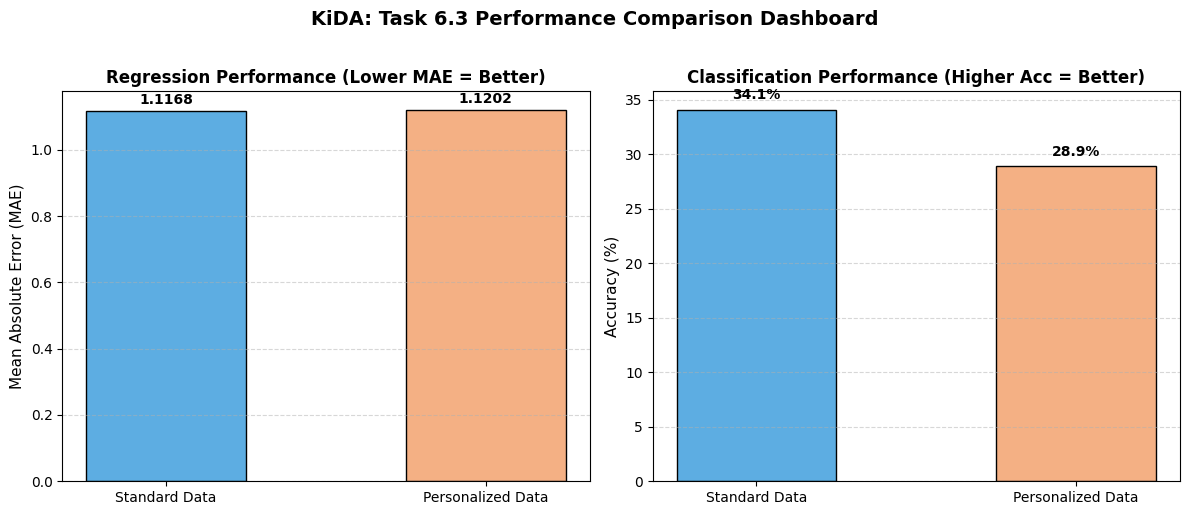

In [185]:
import matplotlib.pyplot as plt

# Using the exact MAE values from your training notebook runs
mae_baseline = 1.1168
mae_personalized = 1.1202

# Convert classification accuracy to an intuitive "Approximate Error" metric for side-by-side display
# or plot them as a structured performance breakdown dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Regression Performance (Lower is better)
ax1.bar(["Standard Data", "Personalized Data"], [mae_baseline, mae_personalized], color=["#5dade2", "#f4b084"], edgecolor="black", width=0.5)
ax1.set_ylabel("Mean Absolute Error (MAE)", fontsize=11)
ax1.set_title("Regression Performance (Lower MAE = Better)", fontweight="bold")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate([mae_baseline, mae_personalized]):
    ax1.text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")

# Plot 2: Classification Performance (Higher is better)
ax2.bar(["Standard Data", "Personalized Data"], [std_clf_acc * 100, pers_clf_acc * 100], color=["#5dade2", "#f4b084"], edgecolor="black", width=0.5)
ax2.set_ylabel("Accuracy (%)", fontsize=11)
ax2.set_title("Classification Performance (Higher Acc = Better)", fontweight="bold")
ax2.grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate([std_clf_acc * 100, pers_clf_acc * 100]):
    ax2.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("KiDA: Task 6.3 Performance Comparison Dashboard", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()